# Notebook 01 — POD Basis Construction

Global POD basis $V_n \in \mathbb{R}^{N \times n}$ from all training trajectories.

We work with **drawdown** $\Delta p(t) = p(t) - p_{\text{init}}$ so the initial condition is zero everywhere. The basis is built from schedule 1 only across all 49 $(k, S)$ parameter points.

## 0. Imports and paths

In [21]:
import json
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'

TRAINING_DIR = Path('../data/01_training')
BASIS_DIR    = Path('../rom/basis')
BASIS_DIR.mkdir(parents=True, exist_ok=True)

P_INIT  = 4500.0
N_CELLS = 2500
K_GRID  = [10, 20, 50, 100, 200, 300]
S_GRID  = [0,  1,  2,  4,  6,  8]

print(f'Training dir : {TRAINING_DIR.resolve()}')
print(f'Basis dir    : {BASIS_DIR.resolve()}')

Training dir : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Basis dir    : F:\Niloy Deb\Part Two\reservoir_rom\rom\basis


## 1. Load all training snapshots

Schedule 1 only for POD. Diverse schedules are used in NB02 for operator inference.

In [22]:
def load_snapshots(case_name):
    path = TRAINING_DIR / case_name / 'snapshots_psia.mat'
    try:
        return sio.loadmat(str(path), variable_names=['X_psia'])['X_psia']
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            return f['X_psia'][()].T


snapshot_cols = []
cases_used    = []
missing       = []

for k in K_GRID:
    for s in S_GRID:
        name = f'k{k:03d}_s{s:02d}_sched1'
        try:
            X = load_snapshots(name)          # [N, K]
            assert X.shape[0] == N_CELLS, f'Wrong row count: {X.shape}'
            dX = X - P_INIT                   # drawdown [N, K]
            x0 = dX[:, [0]]                   # initial condition [N, 1]
            snapshot_cols.append(x0)
            snapshot_cols.append(dX)
            cases_used.append(name)
        except FileNotFoundError:
            missing.append(name)

if missing:
    print(f'WARNING: {len(missing)} cases not found')

Z = np.hstack(snapshot_cols)   # [N, total_cols]
print(f'Cases used          : {len(cases_used)}')
print(f'Concatenation matrix: {Z.shape}')
print(f'Memory              : {Z.nbytes / 1e6:.1f} MB')

Cases used          : 36
Concatenation matrix: (2500, 12636)
Memory              : 252.7 MB


## 2. Compute SVD

In [23]:
print('Computing SVD...')
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f'U shape     : {U.shape}')
print(f'sigma[0]    : {sigma[0]:.4f}')
print(f'sigma[9]    : {sigma[9]:.6f}')
print(f'sigma[-1]   : {sigma[-1]:.2e}')

Computing SVD...
U shape     : (2500, 2500)
sigma[0]    : 142728.7017
sigma[9]    : 41.925306
sigma[-1]   : 1.28e-13


## 3. Mode selection — energy and projection error

In [24]:
cumulative_energy = np.cumsum(sigma**2) / np.sum(sigma**2)
n_modes_range     = np.arange(1, min(51, len(sigma)+1))

proj_errors = []
for n_try in n_modes_range:
    Vn_try = U[:, :n_try]
    err_n  = 0.0
    for k in K_GRID:
        for s in S_GRID:
            name = f'k{k:03d}_s{s:02d}_sched1'
            try:
                X  = load_snapshots(name) - P_INIT
                Xr = Vn_try @ (Vn_try.T @ X)
                err_n += (np.linalg.norm(X - Xr, 'fro')**2 /
                          np.linalg.norm(X, 'fro')**2)
            except FileNotFoundError:
                pass
    proj_errors.append(err_n / len(cases_used))

proj_errors = np.array(proj_errors)

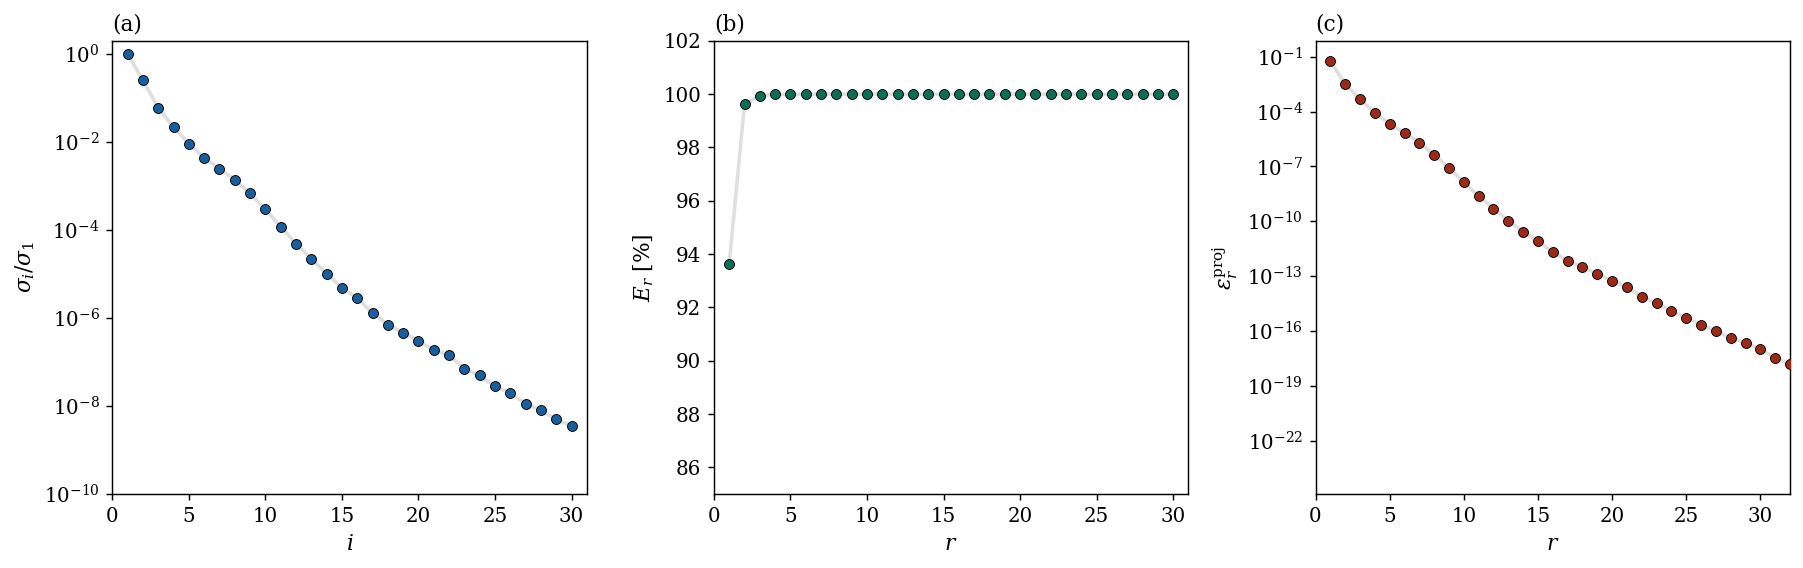

Modes for proj error < 1e-6 : n = 8
Modes for proj error < 1e-7 : 9


In [25]:
sigma_norm = sigma / sigma[0]
cum_pct    = cumulative_energy * 100
N_SHOW     = 30

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

ax = axes[0]
ax.semilogy(range(1, N_SHOW+1), sigma_norm[:N_SHOW],
            'o', color=C1, ms=5.5, mec='k', mew=0.5, zorder=3)
ax.semilogy(range(1, N_SHOW+1), sigma_norm[:N_SHOW],
            color='gray', alpha=0.25, lw=2.0, zorder=1)
ax.set_title('(a)', loc='left', fontweight='normal')
ax.set_xlabel('$i$'); ax.set_ylabel(r'$\sigma_i / \sigma_1$')
ax.set_xlim([0, 31]); ax.set_ylim([1e-10, 2])

ax2 = axes[1]
ax2.plot(range(1, N_SHOW+1), cum_pct[:N_SHOW],
         'o', color=C2, ms=5.5, mec='k', mew=0.5, zorder=3)
ax2.plot(range(1, N_SHOW+1), cum_pct[:N_SHOW],
         color='gray', alpha=0.25, lw=2.0, zorder=1)
ax2.set_title('(b)', loc='left', fontweight='normal')
ax2.set_xlabel('$r$'); ax2.set_ylabel('$E_r$ [%]')
ax2.set_xlim([0, 31]); ax2.set_ylim([85, 102])

ax3 = axes[2]
ax3.semilogy(n_modes_range, proj_errors,
             'o', color=C3, ms=5.5, mec='k', mew=0.5, zorder=3)
ax3.semilogy(n_modes_range, proj_errors,
             color='gray', alpha=0.25, lw=2.0, zorder=1)
ax3.set_title('(c)', loc='left', fontweight='normal')
ax3.set_xlabel('$r$'); ax3.set_ylabel(r'$\varepsilon_r^{\mathrm{proj}}$')
ax3.set_xlim([0, 32])

plt.tight_layout()
plt.savefig('fig_pod_convergence.pdf', dpi=150, bbox_inches='tight')
plt.show()

n_1em6 = int(np.argmax(proj_errors < 1e-6)) + 1
print(f'Modes for proj error < 1e-6 : n = {n_1em6}')
print(f'Modes for proj error < 1e-7 : {int(np.argmax(proj_errors < 1e-7))+1 if np.any(proj_errors < 1e-7) else "not reached"}')

## 4. Select n modes

`N_MODES = 15` captures the near-well pressure cone across all 49 (k, S) parameter points. Increase to 20 if `proj_errors[14] > 1e-4`.

In [26]:
N_MODES = 10   # increase to 20 if proj_errors[14] > 1e-4

Vn = U[:, :N_MODES]

per_case_errors = {}
for k in K_GRID:
    for s in S_GRID:
        name = f'k{k:03d}_s{s:02d}_sched1'
        try:
            X   = load_snapshots(name) - P_INIT
            Xr  = Vn @ (Vn.T @ X)
            err = np.linalg.norm(X - Xr, 'fro')**2 / np.linalg.norm(X, 'fro')**2
            per_case_errors[name] = err
        except FileNotFoundError:
            pass

errors = np.array(list(per_case_errors.values()))
print(f'N_MODES : {N_MODES}')
print(f'Vn shape: {Vn.shape}')
print(f'Mean proj error : {errors.mean():.2e}')
print(f'Max  proj error : {errors.max():.2e}')
print(f'Worst case      : {max(per_case_errors, key=per_case_errors.get)}')

N_MODES : 10
Vn shape: (2500, 10)
Mean proj error : 1.35e-08
Max  proj error : 5.64e-08
Worst case      : k010_s04_sched1


## 5. Spatial mode visualisation

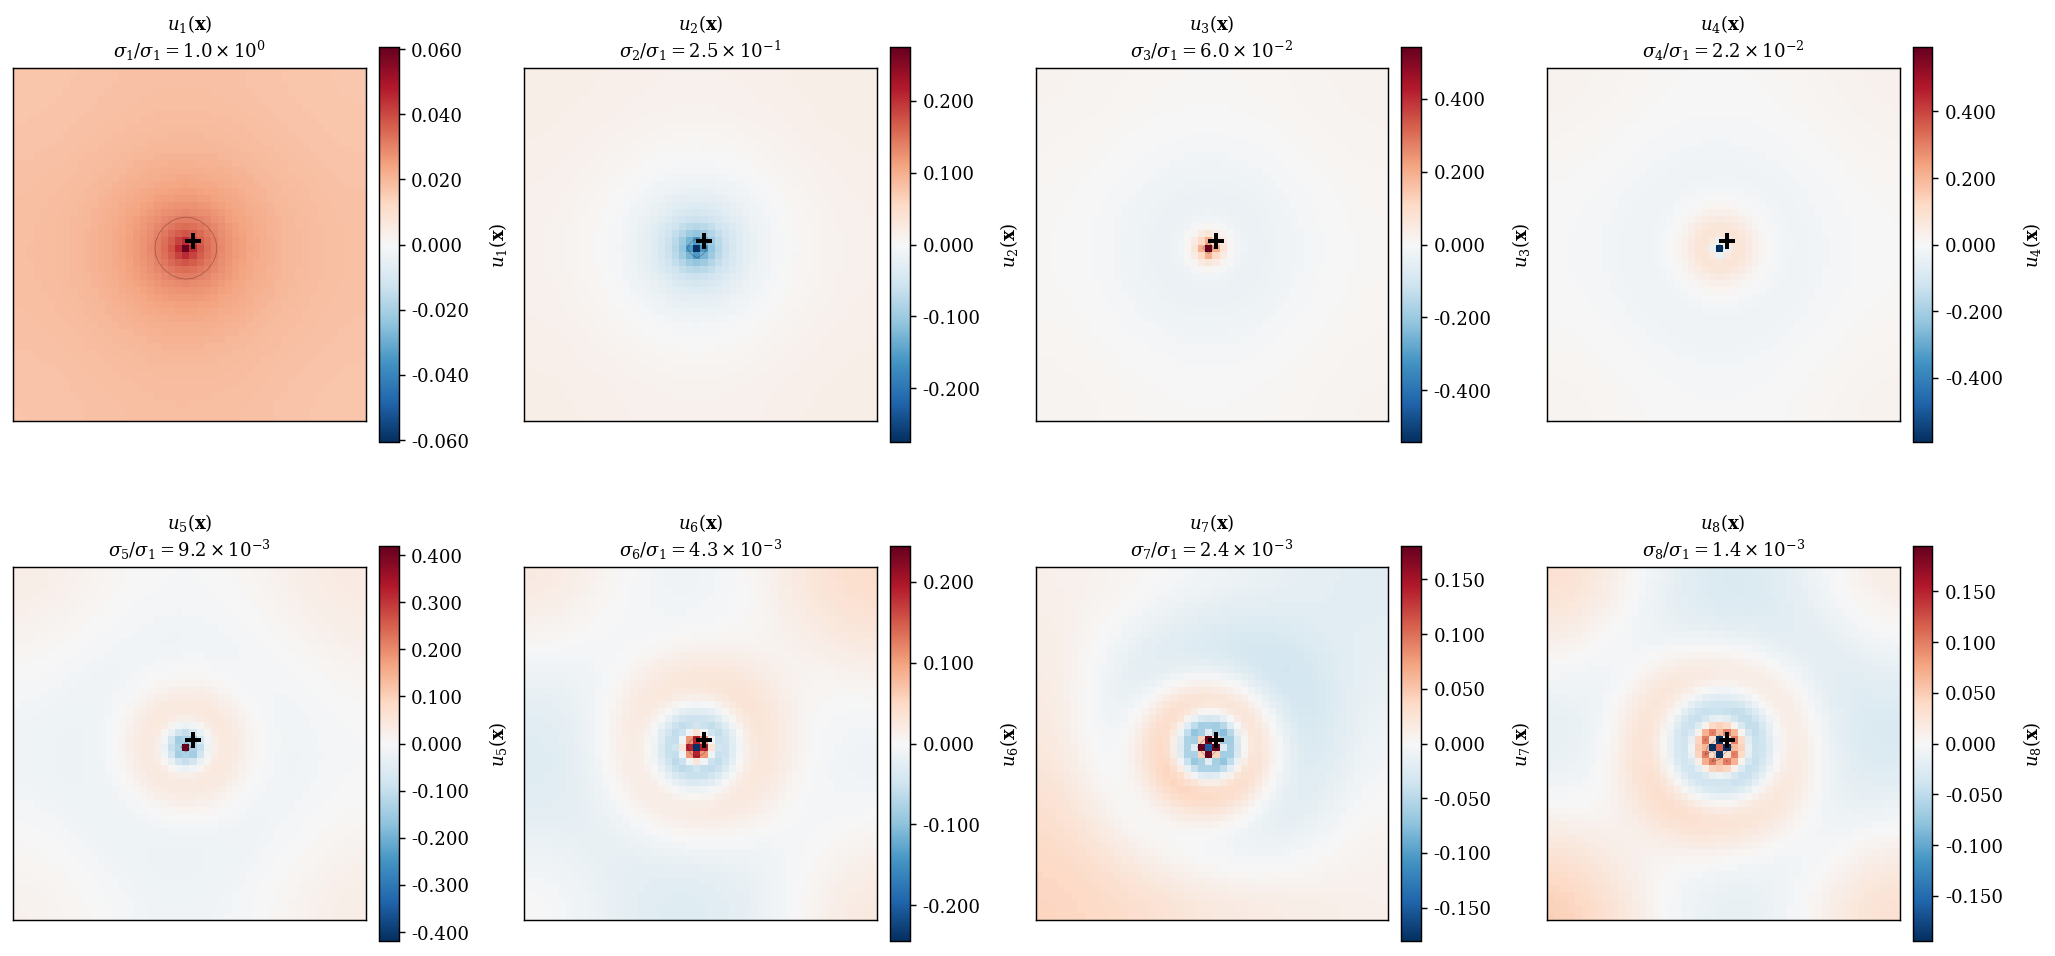

In [27]:
NX, NY   = 50, 50
n_show   = min(N_MODES, 8)

fig, axes = plt.subplots(2, 4, figsize=(4.0*4, 4.0*2))

for i in range(n_show):
    ax      = axes[i // 4, i % 4]
    mode_map = U[:, i].reshape(NY, NX)
    vm      = np.abs(mode_map).max()

    im = ax.imshow(mode_map, origin='lower', cmap='RdBu_r',
                   vmin=-vm, vmax=vm, aspect='equal')
    ax.plot(NX//2, NY//2, 'k+', ms=9, mew=2.2, zorder=10)
    ax.contour(np.abs(mode_map), levels=[vm*0.5],
               colors=['k'], linewidths=0.4, alpha=0.3)

    sv_norm = sigma[i] / sigma[0]
    m_val   = f'{sv_norm:.1e}'.split('e')[0]
    e_val   = int(f'{sv_norm:.1e}'.split('e')[1])
    ax.set_title(f'$u_{{{i+1}}}(\\mathbf{{x}})$\n'
                 f'$\\sigma_{{{i+1}}}/\\sigma_1 = {m_val}\\times10^{{{e_val}}}$',
                 fontsize=10, pad=6)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

    cb = plt.colorbar(im, ax=ax, shrink=0.82, format='%.3f', pad=0.03)
    cb.set_label(rf'$u_{{{i+1}}}(\mathbf{{x}})$', fontsize=10,
                 rotation=90, labelpad=10)
    cb.ax.tick_params(labelsize=10)

plt.tight_layout(w_pad=0.4, h_pad=1.2)
plt.savefig('fig_pod_modes_spatial.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 6. Orthogonality check

In [28]:
VtV          = Vn.T @ Vn
off_diag_max = np.abs(VtV - np.eye(N_MODES)).max()
diag_min     = np.diag(VtV).min()

print(f'Vn shape          : {Vn.shape}')
print(f'max |VnT Vn - I|  : {off_diag_max:.2e}  (should be ~1e-15)')
print(f'min diagonal entry: {diag_min:.10f}  (should be 1.0)')

if off_diag_max < 1e-10:
    print('Basis is orthonormal')
else:
    print('Orthogonality check FAILED — re-run SVD')

Vn shape          : (2500, 10)
max |VnT Vn - I|  : 1.22e-15  (should be ~1e-15)
min diagonal entry: 1.0000000000  (should be 1.0)
Basis is orthonormal


## 7. Reconstruction spot check

Case           : k050_s02_sched1
Snapshot index : 175
Relative error : 2.38e-03


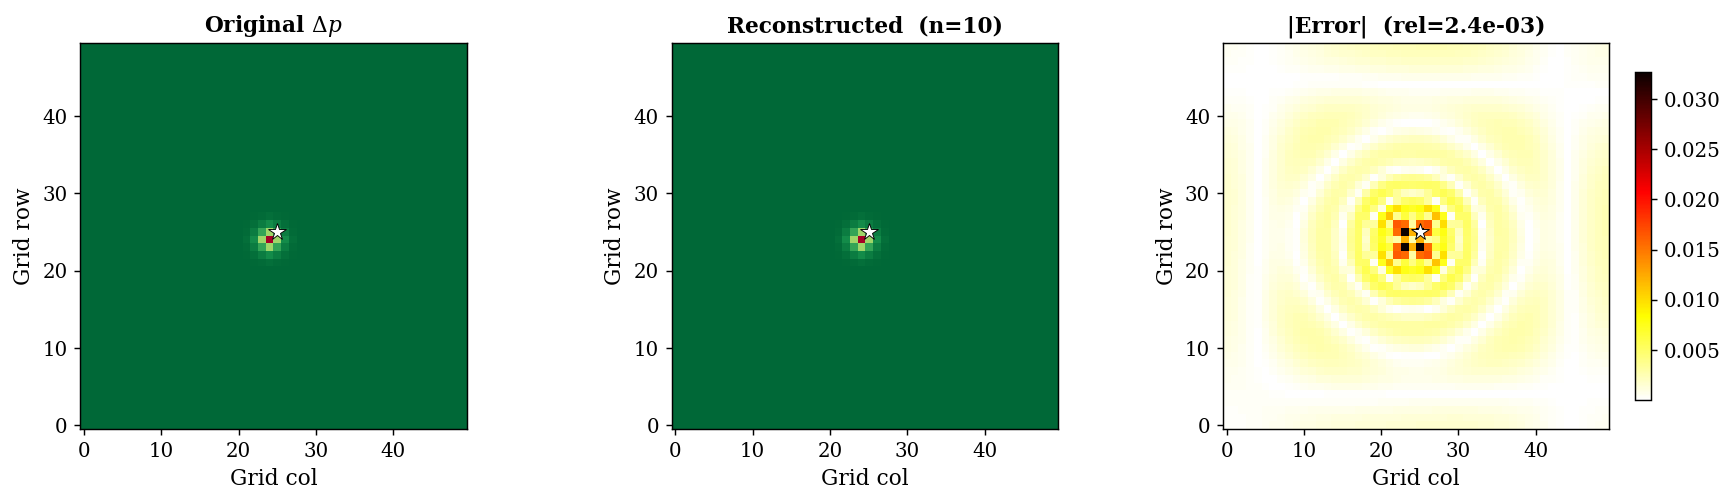

In [29]:
test_case = 'k050_s02_sched1'
X_full   = load_snapshots(test_case) - P_INIT
snap_idx = X_full.shape[1] // 2

x_orig  = X_full[:, snap_idx]
x_recon = Vn @ (Vn.T @ x_orig)
x_err   = x_orig - x_recon

rel_err = np.linalg.norm(x_err) / np.linalg.norm(x_orig)
print(f'Case           : {test_case}')
print(f'Snapshot index : {snap_idx}')
print(f'Relative error : {rel_err:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmin = min(x_orig.min(), x_recon.min())
vmax = max(x_orig.max(), x_recon.max())

axes[0].imshow(x_orig.reshape(NY, NX), origin='lower',
               cmap='RdYlGn', vmin=vmin, vmax=vmax)
axes[0].set_title('Original $\\Delta p$')

axes[1].imshow(x_recon.reshape(NY, NX), origin='lower',
               cmap='RdYlGn', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Reconstructed  (n={N_MODES})')

im = axes[2].imshow(np.abs(x_err).reshape(NY, NX),
                    origin='lower', cmap='hot_r')
axes[2].set_title(f'|Error|  (rel={rel_err:.1e})')
plt.colorbar(im, ax=axes[2], shrink=0.85)

for ax in axes:
    ax.plot(NY//2, NX//2, 'w*', ms=10,
            markeredgecolor='k', markeredgewidth=0.5)
    ax.set_xlabel('Grid col'); ax.set_ylabel('Grid row')

plt.tight_layout(); plt.show()

## 8. Save basis

In [30]:
assert Vn.shape == (N_CELLS, N_MODES), \
    f'Vn shape {Vn.shape} does not match expected ({N_CELLS}, {N_MODES})'

np.save(BASIS_DIR / 'Vn.npy',              Vn)
np.save(BASIS_DIR / 'singular_values.npy', sigma)
np.save(BASIS_DIR / 'p_mean.npy',          np.array([P_INIT]))

metadata = {
    'n_modes'          : int(N_MODES),
    'N_cells'          : int(N_CELLS),
    'p_init_psia'      : float(P_INIT),
    'projection_error' : float(proj_errors[N_MODES - 1]),
    'cumulative_energy': float(cumulative_energy[N_MODES - 1]),
    'sigma_n'          : float(sigma[N_MODES - 1]),
    'sigma_1'          : float(sigma[0]),
    'n_training_cases' : len(cases_used),
    'training_cases'   : cases_used,
    'svd_matrix_shape' : list(Z.shape),
}

with open(BASIS_DIR / 'basis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
for p in sorted(BASIS_DIR.iterdir()):
    print(f'  {p.name:<30} {p.stat().st_size / 1e3:.1f} kB')
print(f'\nReady for NB02 — Operator Inference')
print(f'  Vn   : {Vn.shape}')
print(f'  n    : {N_MODES}')
print(f'  error: {proj_errors[N_MODES-1]:.2e}')

Saved:
  basis_metadata.json            1.2 kB
  p_mean.npy                     0.1 kB
  singular_values.npy            20.1 kB
  Vn.npy                         200.1 kB

Ready for NB02 — Operator Inference
  Vn   : (2500, 10)
  n    : 10
  error: 1.35e-08
